# Данные — семпл поисковых запросов к Яндекс.Картинкам за несколько недель.

## Загрузка данных, изучение общей информации

- Импортируем необходимые библиотеки

In [21]:
import pandas as pd
from matplotlib import pyplot as plt
import missingno as msno
import seaborn as sns
from matplotlib.patches import Patch
from pandasql import sqldf

- Прочитаем файлы с данными и изучим общую информацию 

In [2]:
#прочитаем файлы с данными 
df = pd.read_csv('/Users/anna/Desktop/Яндекс/Аналитика/data.tsv', sep='\t', header=None)

# отображение всех колонок при выводе на экран
pd.set_option('display.max_columns', None)

# выведем первые 5 строк фрейма для ознакомления
df.head()

,0,1,2
0,малевич картины,1631806465,desktop
1,психология,1631781583,touch
2,с днём рождения лена,1631771563,touch
3,зверополис фильмы,1631787599,touch
4,алабай собака фото,1631786645,touch


- Файл без заголовков. Переименуем колонки и сразу переведем Timestamp в московское время (UTC+3), т.к. сервис российский.


In [3]:
# переименуем колонки
df.columns = ['query', 'ts', 'platform']

# переведём Timestamp в московское время (UTC+3), т.к. сервис российский
df['dt_msk'] = pd.to_datetime(df['ts'], unit='s') + pd.Timedelta(hours=3)

df.head()

,query,ts,platform,dt_msk
0,малевич картины,1631806465,desktop,2021-09-16 18:34:25
1,психология,1631781583,touch,2021-09-16 11:39:43
2,с днём рождения лена,1631771563,touch,2021-09-16 08:52:43
3,зверополис фильмы,1631787599,touch,2021-09-16 13:19:59
4,алабай собака фото,1631786645,touch,2021-09-16 13:04:05


- Изучим краткую информацию о данных

In [4]:
# создадим универсальную функцию для вывода сводной информации о датафрейме
def oll_dataframes_info(name_of_dataframes): 
    print('\033[1m' + 'Краткое описание структуры данных:' + '\033[0m')
    name_of_dataframes.info()
    print('*'*50)
    
    print('\033[1m' + 'Количество явных дубликатов датафрейма:' + '\033[0m')
    display(name_of_dataframes.duplicated().sum())
    print('*'*50)
 
    print('\033[1m' + 'Пропуски данных датафрема:' + '\033[0m')
    display(name_of_dataframes.isna().sum())
    print('*'*50)
    
    if 'platform' in name_of_dataframes.columns:
        print('\033[1m' + 'Баланс платформ:' + '\033[0m')
        display(name_of_dataframes['platform'].value_counts())
        print('\033[1m' + 'Баланс платформ, % от общего числа:' + '\033[0m')
        display((name_of_dataframes['platform'].value_counts(normalize=True) * 100).round(2))
        print('*'*50)
    
    if 'dt_msk' in name_of_dataframes.columns:
        print('\033[1m' + 'Диапазон дат (MSK):' + '\033[0m')
        print('Начало:', name_of_dataframes['dt_msk'].min())
        print('Конец:', name_of_dataframes['dt_msk'].max())
        print('*'*50)
    
    plt.figure(figsize=(20, 15))
    msno.bar(name_of_dataframes)
    plt.title('Пропуски в данных датафрейма', fontsize=16)
    plt.show() 

Информация о датафрейме:
Краткое описание структуры данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114365 entries, 0 to 1114364
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype         
---  ------    --------------    -----         
 0   query     1114365 non-null  object        
 1   ts        1114365 non-null  int64         
 2   platform  1114365 non-null  object        
 3   dt_msk    1114365 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 34.0+ MB
**************************************************
Количество явных дубликатов датафрейма:


np.int64(435)

**************************************************
Пропуски данных датафрема:


query       0
ts          0
platform    0
dt_msk      0
dtype: int64

**************************************************
Баланс платформ:


platform
touch      726101
desktop    388264
Name: count, dtype: int64

Баланс платформ, % от общего числа:


platform
touch      65.16
desktop    34.84
Name: proportion, dtype: float64

**************************************************
Диапазон дат (MSK):
Начало: 2021-09-01 00:00:00
Конец: 2021-09-21 23:59:59
**************************************************


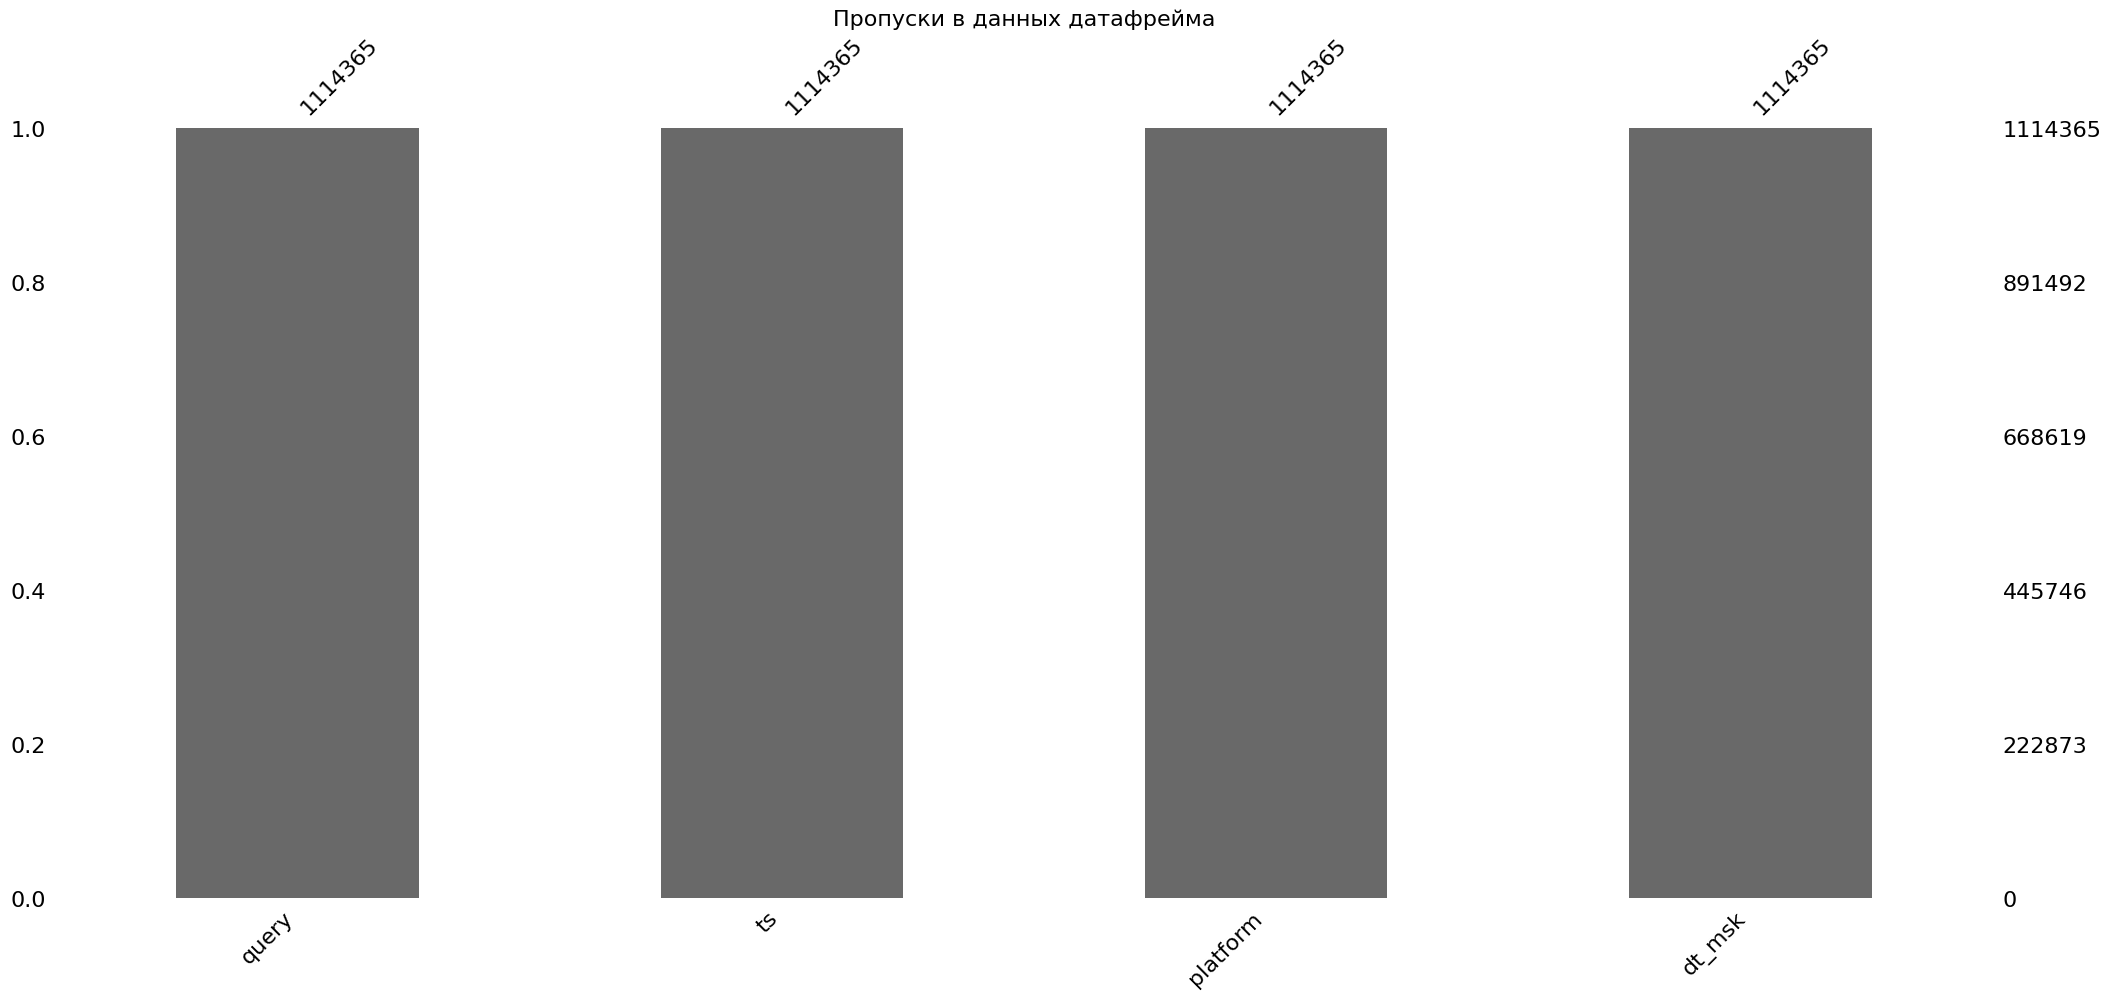

In [5]:
#изучим информацию о датафрейме 
for row in [df]:
    print('\033[1m' + 'Информация о датафрейме:' + '\033[0m')
    oll_dataframes_info(row)

**Краткий вывод:**
1. В исходном датафрейме 3 колонки и 1 114 365 строк.
2. Столбец времени хранился в виде unix-timestamp; для отображения корректной даты и времени создан новый столбец `dt_msk` (переведён в московское время, UTC+3).
3. Пропусков в данных нет.
4. Данные охватывают период с 1 по 21 сентября 2021 года.
5. Запросов с мобильных/сенсорных устройств (touch) больше — 726,1 тыс. запросов (65,2% от общего числа), чем с компьютера (desktop) — 388,3 тыс. запросов (34,8% от общего числа).
6. Количество явных дубликатов — 435 запросов, что составляет 0,04% от общего числа запросов.
   
   Проверим что это за дубликаты и как поступить с ними дальше

In [6]:
# посмотрим на явные дубликаты подробнее
duplicates = df[df.duplicated(keep=False)].sort_values(['query', 'ts'])
duplicates.head(20)

,query,ts,platform,dt_msk
7246,1 сентября,1630466458,touch,2021-09-01 06:20:58
723221,1 сентября,1630466458,touch,2021-09-01 06:20:58
338172,1 сентября,1630469068,touch,2021-09-01 07:04:28
467839,1 сентября,1630469068,touch,2021-09-01 07:04:28
748175,1 сентября,1630469534,touch,2021-09-01 07:12:14
1030866,1 сентября,1630469534,touch,2021-09-01 07:12:14
41375,1 сентября,1630473960,touch,2021-09-01 08:26:00
763870,1 сентября,1630473960,touch,2021-09-01 08:26:00
421784,1 сентября,1630475414,touch,2021-09-01 08:50:14
811142,1 сентября,1630475414,touch,2021-09-01 08:50:14


In [7]:
# какие платформы у дубликатов
print('Платформы у дубликатов:')
print(duplicates['platform'].value_counts())
print('*'*50)

# проверим у каждой ли группы только 2 копии или есть и больше
print('Размер групп дубликатов (сколько раз повторяется каждая уникальная комбинация query+ts+platform):')
dup_counts = df[df.duplicated(keep=False)].groupby(['query', 'ts', 'platform']).size()
print(dup_counts.value_counts())
print('*'*50)

# проверим в какие дни появляются дубликаты: в конкретные дни? или это не зависит от дат
print('Распределение дубликатов по датам:')
print(duplicates['dt_msk'].dt.date.value_counts().sort_index())
print('*'*50)

# топ самых частых запросов среди дублей
print('Топ-10 самых частых запросов среди дубликатов:')
print(duplicates['query'].value_counts().head(10))

Платформы у дубликатов:
platform
touch      718
desktop    147
Name: count, dtype: int64
**************************************************
Размер групп дубликатов (сколько раз повторяется каждая уникальная комбинация query+ts+platform):
2    425
3      5
Name: count, dtype: int64
**************************************************
Распределение дубликатов по датам:
dt_msk
2021-09-01    186
2021-09-02     39
2021-09-03     18
2021-09-04     16
2021-09-05     16
2021-09-06     24
2021-09-07     28
2021-09-08     51
2021-09-09     26
2021-09-10     36
2021-09-11     16
2021-09-12     20
2021-09-13     28
2021-09-14     44
2021-09-15     32
2021-09-16     37
2021-09-17     36
2021-09-18     41
2021-09-19     35
2021-09-20     38
2021-09-21     98
Name: count, dtype: int64
**************************************************
Топ-10 самых частых запросов среди дубликатов:
query
с 1 сентября                         56
с днём рождения женщине              36
календарь 2021                       

**Краткий вывод:**

435 дубликатов (0,04% от данных) сконцентрированы в дни праздников - 1 сентября (186 шт.) и 21 сентября (98 шт.), тогда как в остальные дни их фоновый уровень 16 - 51. Это не случайно: 1 сентября - День знаний, 21 сентября - Рождество Пресвятой Богородицы (церковный праздник, фиксированная дата). Состав дублей это подтверждает - топ запросов среди них: "с 1 сентября", "с днём знаний", "с рождеством пресвятой богородицы".

Без user_id нельзя точно определить, единичные ли это технические повторы или совпадения запросов разных пользователей в момент пикового спроса. Учитывая малую долю (0,04%) и правдоподобность естественного совпадения при высоком одновременном спросе на праздничные темы, дубликаты оставлены в данных без изменений — риск занизить праздничный трафик перевешивает риск небольшого завышения частот.

## Раздел 1. Диапазон дат 

Данные в датафрейме покрывают период с **1 по 21 сентября 2021 года** — ровно 3 недели.

При переводе времени из UTC в московское (UTC+3) была добавлена поправка `+3 часа`. Это важно: без неё границы диапазона выглядели бы «неровно» — 31 августа, 21:00 — 21 сентября, 20:59:59 (в исходном UTC), тогда как сервис российский и логичнее анализировать данные в местном времени пользователей.

## Раздел 2. Запросы со словом "ютуб" по платформам 

Продублируем расчёт доли запросов про "ютуб" по платформам (раздел 2) двумя способами: pandas и sql чтобы сверить результат.

- Запрос pandas

In [18]:
# найдём все запросы, содержащие "ютуб" (регистронезависимо)
mask_yt = df['query'].str.contains('ютуб', case=False, na=False)

print('Абсолютное количество запросов про "ютуб" по платформам:')
abs_counts = df[mask_yt]['platform'].value_counts()
print(abs_counts)
print('*'*50)

print('Доля запросов про "ютуб" от всего трафика платформы, %:')
total_counts = df['platform'].value_counts()
share = (abs_counts / total_counts * 100).round(3)
print(share)
print('*'*50)

print('Топ-20 самых частых запросов, содержащих "ютуб":')
print(df[mask_yt]['query'].value_counts().head(20))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Абсолютное количество запросов про "ютуб" по платформам:
platform
desktop    806
touch      732
Name: count, dtype: int64
**************************************************
Доля запросов про "ютуб" от всего трафика платформы, %:
platform
desktop    0.208
touch      0.101
Name: count, dtype: float64
**************************************************
Топ-20 самых частых запросов, содержащих "ютуб":
query
ютуб                     1190
Ютуб                      139
ютуб youtube               70
шапка для ютуба            35
а4 ютуб                    34
ютуб видеохостинг          33
скачать видео с ютуба      21
леди диана ютуб            16
Name: count, dtype: int64


- Запрос sql

In [22]:
# сначала приводим к нижнему регистру наименования средствами Python (pandas), а не SQL:
# встроенный LOWER() в SQLite не умеет работать с кириллицей,
# из-за этого "Ютуб" с большой буквы не находился бы через LOWER(query) LIKE '%ютуб%'
df['query_low'] = df['query'].str.lower()

# теперь запрос sql
query = """
SELECT
    platform,
    -- считаем запросы с "ютуб" (регистр уже приведён в query_low)
    SUM(CASE WHEN query_low LIKE '%ютуб%' THEN 1 ELSE 0 END) AS yt_count,
    -- общее число запросов на платформе
    COUNT(*) AS total_count,
    -- доля от трафика платформы, %
    ROUND(100.0 * SUM(CASE WHEN query_low LIKE '%ютуб%' THEN 1 ELSE 0 END) / COUNT(*), 3) AS yt_share_pct
FROM df
GROUP BY platform
"""

print('Результат через SQL (pandasql):')
sql_result = sqldf(query, globals())
sql_result

Результат через SQL (pandasql):


,platform,yt_count,total_count,yt_share_pct
0,desktop,806,388264,0.208
1,touch,732,726101,0.101


**Краткий вывод:**
1. Я искала в датафрейме подстроку «ютуб» (регистронезависимо), а не только точное совпадение, чтобы учесть варианты вроде «ютуб видео», «скачать видео с ютуба», «шапка для ютуба». Сравнила как абсолютные числа, так и долю от трафика платформы, т.к. объёмы платформ разные (touch — 65,2% всего трафика, desktop — 34,8%).
2. Абсолютные числа почти равны (desktop — 806, touch — 732), но в долях от трафика платформы desktop оказывается **почти вдвое выше**: 0,21% против 0,10% на touch. Без нормировки на объём платформы можно было бы сделать неверный вывод о том, что интерес к YouTube на платформах примерно одинаковый. На деле даже такая узкая и нейтральная тема, как YouTube, подтверждает общий паттерн: на desktop поиск по картинкам используется более целенаправленно, тогда как на touch он размыт среди множества других фоновых запросов.
3. Проверка топ-20 запросов, попавших под фильтр, показала, что все они действительно релевантны теме YouTube (сам сайт, скачивание видео, оформление канала) — случайных совпадений подстроки не обнаружено.

## Раздел 3. Топ10 самых частотных запросов в каждой платформе

In [9]:
for platform in ['desktop', 'touch']:
    print(f'ТОП-10 запросов, platform = {platform}:')
    top10 = df[df['platform'] == platform]['query'].value_counts().head(10)
    print(top10)
    print('*'*50)

ТОП-10 запросов, platform = desktop:
query
календарь 2021                     2804
таблица менделеева                 2631
картинки                           1647
английский алфавит                 1293
обои на рабочий стол               1143
Одноклассники (социальная сеть)    1116
таблица квадратов                   877
алфавит                             874
таблица умножения                   867
карта мира                          795
Name: count, dtype: int64
**************************************************
ТОП-10 запросов, platform = touch:
query
с днём рождения женщине    4903
с днём рождения            3967
с днём рождения мужчине    3623
с днем рождения            3005
погода                     2840
игры                       2833
фильмы                     2746
новости                    2708
музыка                     2696
мода                       2648
Name: count, dtype: int64
**************************************************


**Наблюдение:** в топ-10 touch тема "с днём рождения" встречается сразу в 4 разных формулировках ("с днём рождения женщине", "с днём рождения", "с днём рождения мужчине", "с днем рождения" без ё). Это может искусственно "размазывать" реальный вес темы по нескольким строкам топа. Проверим, насколько велика эта тема, если объединить все формулировки.

In [10]:
mask_birthday = df['query'].str.contains('с днем рождения|с днём рождения', case=False, na=False, regex=True)

print('Суммарное количество запросов "с днём рождения" (все формулировки) по платформам:')
print(df[mask_birthday]['platform'].value_counts())
print('*'*50)

print('Для сравнения — топ-10 запросов touch с объединённой темой "с днём рождения":')
touch_top = df[df['platform'] == 'touch']['query'].value_counts().head(10)
birthday_total = df[(df['platform'] == 'touch') & mask_birthday].shape[0]
print(f'"с днём рождения" (объединено): {birthday_total}')
print(touch_top[~touch_top.index.str.contains('день рождения|днем рождения|днём рождения', case=False, regex=True)])

Суммарное количество запросов "с днём рождения" (все формулировки) по платформам:
platform
touch      55213
desktop     5577
Name: count, dtype: int64
**************************************************
Для сравнения — топ-10 запросов touch с объединённой темой "с днём рождения":
"с днём рождения" (объединено): 55213
query
погода     2840
игры       2833
фильмы     2746
новости    2708
музыка     2696
мода       2648
Name: count, dtype: int64


**Краткий вывод:**
После объединения формулировок картина поменялась в корне: на touch теперь **55 213 запросов** с темой "с днём рождения" — против отдельных 4903/3967/3623/3005 по разным формулировкам, которые до объединения не выглядели доминирующими.

In [11]:
mask_birthday = df['query'].str.contains('с днем рождения|с днём рождения', case=False, na=False, regex=True)

# копия df, чтобы не менять исходные данные
df2 = df.copy()
df2.loc[mask_birthday, 'query'] = 'с днём рождения (объединено)'

for platform in ['desktop', 'touch']:
    print(f'ТОП-10 запросов (с объединённой темой ДР), platform = {platform}:')
    print(df2[df2['platform'] == platform]['query'].value_counts().head(10))
    print('*'*50)

ТОП-10 запросов (с объединённой темой ДР), platform = desktop:
query
с днём рождения (объединено)       5577
календарь 2021                     2804
таблица менделеева                 2631
картинки                           1647
английский алфавит                 1293
обои на рабочий стол               1143
Одноклассники (социальная сеть)    1116
таблица квадратов                   877
алфавит                             874
таблица умножения                   867
Name: count, dtype: int64
**************************************************
ТОП-10 запросов (с объединённой темой ДР), platform = touch:
query
с днём рождения (объединено)    55213
погода                           2840
игры                             2833
фильмы                           2746
новости                          2708
музыка                           2696
мода                             2648
спорт                            2643
наука                            2639
технологии                       2631
Name: c

**Краткий вывод:**

При исходном подсчёте (без объединения формулировок) топ-10 запросов на desktop и touch отличаются по смыслу почти полностью — пересечений нет вообще.
**Desktop** — справочно-утилитарные запросы: "календарь 2021", "таблица менделеева", "английский алфавит", "обои на рабочий стол", "таблица квадратов", "таблица умножения", "карта мира". Похоже на запросы "для дела" - учёбы, работы, поиска конкретного изображения для использования (распечатать, вставить в документ/презентацию).

**Touch** — досуговые и бытовые запросы: "погода", "игры", "фильмы", "новости", "музыка", "мода", "спорт", "наука", "технологии" — набор общих тематических категорий, похожий на разделы новостного/контентного приложения.

**Отдельное наблюдение:** в исходном топ-10 touch тема поздравлений "с днём рождения" была "размазана" по 4 формулировкам ("женщине", "мужчине", без уточнения, без "ё") и не выглядела доминирующей. После объединения всех формулировок в одну категорию оказалось, что она кратно превосходит любую другую тему топа: **55 213 запросов на touch (7,6% всего трафика платформы)** против **5 577 на desktop (1,44%)** — почти в 5 раз выше в относительном выражении.

Это говорит о том, что мобильный поиск по картинкам активно используется как инструмент для бытовых нужд "здесь и сейчас" (найти открытку, отправить в мессенджере), тогда как на desktop таким сценарием пользуются существенно реже — там доминируют более "рабочие"/справочные интенты.

## Раздел 4. Отличие трафика запросов в течении дня

Необходимо посмотреть долю запросов от суммы запросов платформы за час, а не абсолютные числа — иначе платформа с большим трафиком (touch) визуально "перекроет" Desktop

Доля запросов по часам суток, % от трафика платформы:
platform  desktop  touch
hour                    
0            1.61   2.02
1            0.93   1.24
2            0.64   0.95
3            0.58   0.96
4            0.72   1.22
5            1.03   1.70
6            1.58   2.76
7            2.41   4.00
8            3.59   5.59
9            4.76   5.94
10           5.32   5.95
11           5.70   5.12
12           6.00   5.12
13           6.24   5.04
14           6.56   5.11
15           6.79   5.13
16           6.96   5.24
17           6.66   5.30
18           6.53   5.44
19           6.58   5.60
20           6.40   6.35
21           5.56   6.04
22           4.15   5.02
23           2.71   3.16
**************************************************


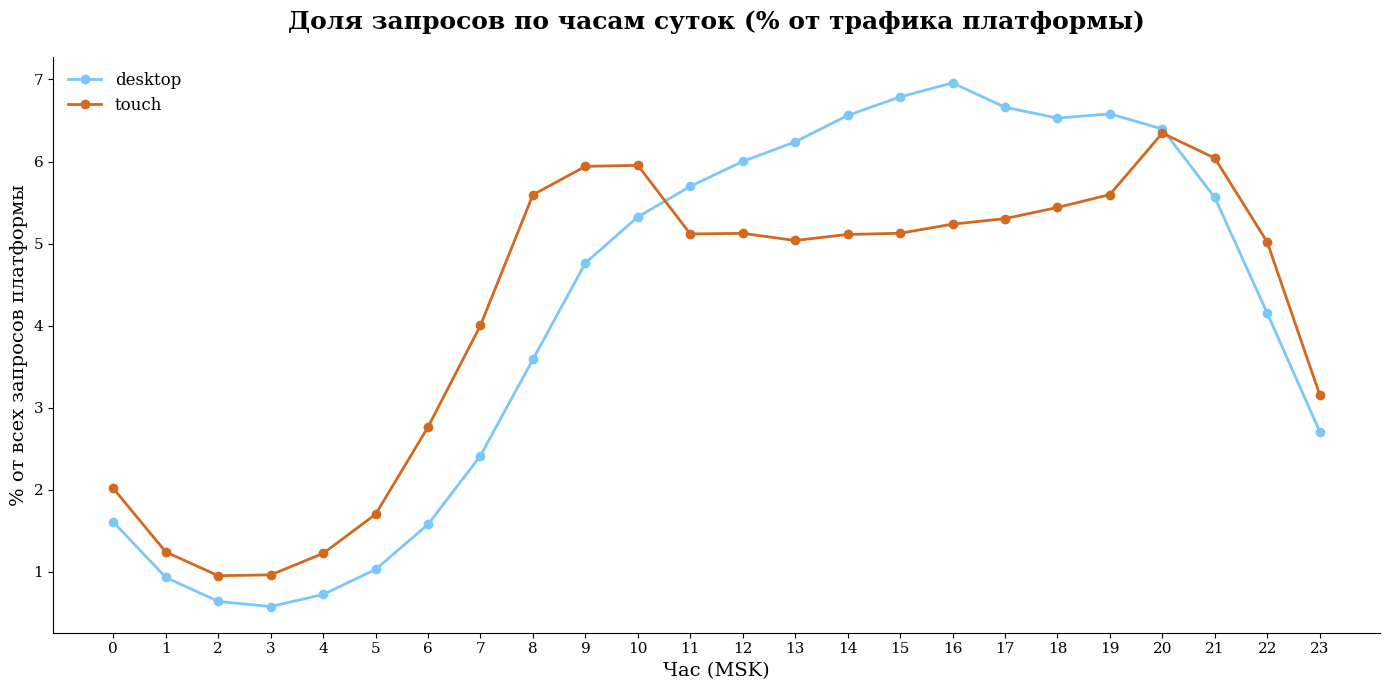

In [12]:
# создадим в датафрейме новую колонку hour, чтобы анализировать данные по часам в течении дня 
df['hour'] = df['dt_msk'].dt.hour

# сгруппируем данные по часам и платформам
pivot = df.groupby(['hour', 'platform']).size().unstack()

# посчитаем долю по часам 
pivot_share = pivot / pivot.sum() * 100

print('Доля запросов по часам суток, % от трафика платформы:')
print(pivot_share.round(2))
print('*'*50)

# создадим график
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(pivot_share.index, pivot_share['desktop'], marker='o', linewidth=2, label='desktop', color='#7bc8f6')
ax.plot(pivot_share.index, pivot_share['touch'], marker='o', linewidth=2, label='touch', color='#d2691e')

ax.set_title('Доля запросов по часам суток (% от трафика платформы)', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Час (MSK)', fontsize=14)
ax.set_ylabel('% от всех запросов платформы', fontsize=14)
ax.set_xticks(range(0, 24))
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

ax.legend(fontsize=12, loc='upper left', frameon=False)

sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()

**Краткий вывод:**
Обе платформы показывают выраженный суточный ритм с минимумом в 2-4 часа ночи, но форма распределения отличается:

- **Touch** быстрее набирает активность утром (5-9 часов) — телефон используется практически сразу после пробуждения, до того как человек садится за компьютер.
- Около **11:00** линии пересекаются: до этого момента touch выше desktop, после — наоборот.
- **Desktop** доминирует в дневные "рабочие" часы (11:00-20:00) с пиком около 16:00 — похоже на использование картиночного поиска как рабочего/учебного инструмента в течение дня.
- **Touch** снова обгоняет desktop вечером (20:00-21:00) — люди откладывают компьютер и возвращаются к телефону после работы.

Общий вывод: desktop привязан к "рабочему" времени дня и месту (сидя за компьютером), тогда как touch сопровождает пользователя на протяжении почти всего дня, с пиками в переходные моменты — сразу после пробуждения и сразу после окончания рабочего дня.

## Раздел 5. Тематики запросов, контрастные для мобильных устройств и компьютеров

Для определения категорий, посмотрим топ-40 запросов по каждой платформе, чтобы понять, какие тематические категории имеет смысл выделить

In [13]:
for platform in ['desktop', 'touch']:
    print(f'=== TOP-40 {platform} ===')
    print(df[df['platform'] == platform]['query'].value_counts().head(40))
    print()

=== TOP-40 desktop ===
query
календарь 2021                                     2804
таблица менделеева                                 2631
картинки                                           1647
английский алфавит                                 1293
обои на рабочий стол                               1143
Одноклассники (социальная сеть)                    1116
таблица квадратов                                   877
алфавит                                             874
таблица умножения                                   867
карта мира                                          795
календарь на 2022 год с праздниками и выходными     757
формулы сокращенного умножения                      736
ютуб                                                714
раскраски                                           704
игры                                                700
календарь 2022                                      658
YouTube                                             648
карта россии       

### Как определены категории

Готовой тематической разметки запросов в данных нет, поэтому категории выделены вручную по ключевым словам на основе анализа топ-40 самых частотных запросов на каждой платформе.

**Логика формирования категорий:**

- **поздравления_праздники** — доминирующая тема на touch: все вариации "с днём рождения", а также "с 1 сентября", "рождество" — темы, которые мы уже разбирали в разделе про дубликаты (привязка к конкретным датам-праздникам).
- **учеба_справочники** — таблицы, алфавит, карты мира/России — заметно выражены на desktop, похоже на учебные/рабочие материалы.
- **навигация_карты** — "карта метро", "схема метро" — выделены отдельно от справочников, т.к. это скорее практическая задача (спланировать маршрут), а не учебная, и встречается почти исключительно на touch.
- **обои_фон** — "обои на рабочий стол", "белый/чёрный фон" — явно desktop-специфичная тема (для мобильного нет аналога "рабочего стола" в этом смысле).
- **творчество_раскраски** — раскраски и рисунки для срисовки — desktop-тема, вероятно связана с последующей распечаткой.
- **развлечения_медиа** — игры, фильмы, музыка, кино, аниме — встречается на обеих платформах, но с разным весом.
- **соцсети** — Одноклассники, ВК и т.п.
- **технологии_гаджеты** — "айфон", "переводчик" — заметно выражены на touch.
- **погода** — отдельная категория, т.к. это частый и однозначный запрос.
- **приветствия** — "доброе утро" — встречается только на touch, нет аналога на desktop.
- **контентные_рубрики** — блок "наука/история/образование/кулинария/здоровье/психология/путешествия/мода/спорт/литература" — однословные тематические запросы, характерные почти исключительно для touch; похоже на рубрики какого-то контентного/новостного приложения или ленты, а не на целевой поиск конкретной картинки.

**Что сознательно не включено в категории:** в топ-40 touch встретился запрос "bokep" (1058 упоминаний, иностранное слово, обозначающее контент для взрослых) — под него отдельная категория не создавалась, он остаётся в неразмеченной части данных.

**Ограничение подхода:** категоризация по ключевым словам покрывает лишь часть данных — длинный хвост уникальных и редких формулировок запросов таким способом не размечается. Для полного покрытия потребовалась бы ML-классификация или готовый тематический справочник, что избыточно для целей тестового задания.

In [14]:
# определим категории
categories = {
    'поздравления_праздники': ['с днем рождения', 'с днём рождения', 'поздравлен', 'открытк', 'с 1 сентября', 'рождеств', 'день знаний', 'с новым годом'],
    'учеба_справочники': ['таблица', 'алфавит', 'формул', 'карта мира', 'карта россии'],
    'навигация_карты': ['карта метро', 'схема метро'],
    'обои_фон': ['обои', 'фон'],
    'творчество_раскраски': ['раскраск', 'рисун', 'срисовки'],
    'развлечения_медиа': ['игры', 'фильм', 'музыка', 'кино', 'аниме', 'сериал'],
    'соцсети': ['одноклассники', ' вк ', 'вконтакте', 'телеграм', 'инстаграм'],
    'технологии_гаджеты': ['айфон', 'iphone', 'переводчик', 'технологи'],
    'погода': ['погода'],
    'приветствия': ['доброе утро'],
    'контентные_рубрики': ['наука', 'история', 'образование', 'кулинария', 'здоровье', 'психология', 'путешестви', 'мода', 'спорт', 'литература'],
}

# функция, которая учитывает, что в категориях должны быть пробелы по краям, чтобы например " вк " не подхватывало "вкусно"
def categorize(q):
    q_low = ' ' + q.lower() + ' '  
    for cat, kws in categories.items():
        for kw in kws:
            if kw in q_low:
                return cat
    return None
    
# применяем функцию к каждой строке колонки query и создаём новую колонку category
df['category'] = df['query'].apply(categorize)

# считаем сколько запросов удалось категоризировать
matched = df['category'].notna().sum()
print(f'Категоризировано: {matched:,} из {len(df):,} запросов ({matched/len(df)*100:.1f}%)')

# смотрим распределение запросов по категориям
print(df['category'].value_counts())

Категоризировано: 302,082 из 1,114,365 запросов (27.1%)
category
поздравления_праздники    82079
контентные_рубрики        54589
учеба_справочники         39236
обои_фон                  31997
развлечения_медиа         31542
творчество_раскраски      21533
технологии_гаджеты        10886
приветствия               10177
навигация_карты            9784
погода                     6480
соцсети                    3779
Name: count, dtype: int64


- Посмотрим в разрезе платформ

In [15]:
# убираем строки без категории (None), иначе попадут в группировку отдельной "пустой" категорией
cat_df = df.dropna(subset=['category'])

# общее число запросов по платформам - нужно для нормировки
total_by_platform = df['platform'].value_counts()

# группируем по категории и платформе, unstack превращает platform в колонки
pivot_cat = cat_df.groupby(['category', 'platform']).size().unstack(fill_value=0)

# переводим в доли (% от трафика платформы), т.к. объёмы платформ разные
pivot_share = (pivot_cat / total_by_platform * 100)

# разница в п.п.: плюс - тема сильнее на desktop, минус - сильнее на touch
pivot_share['diff'] = pivot_share['desktop'] - pivot_share['touch']
pivot_share = pivot_share.sort_values('diff')

print('Доля категории от трафика платформы, % (+ разница desktop-touch, п.п.):')
print(pivot_share.round(3))

Доля категории от трафика платформы, % (+ разница desktop-touch, п.п.):
platform                desktop   touch   diff
category                                      
поздравления_праздники    2.013  10.228 -8.215
контентные_рубрики        2.310   6.283 -3.972
развлечения_медиа         1.930   3.312 -1.382
приветствия               0.151   1.321 -1.170
технологии_гаджеты        0.565   1.197 -0.632
навигация_карты           0.506   1.077 -0.572
погода                    0.252   0.758 -0.506
соцсети                   0.662   0.167  0.495
обои_фон                  3.557   2.504  1.053
учеба_справочники         5.220   2.612  2.607
творчество_раскраски      3.847   0.909  2.938


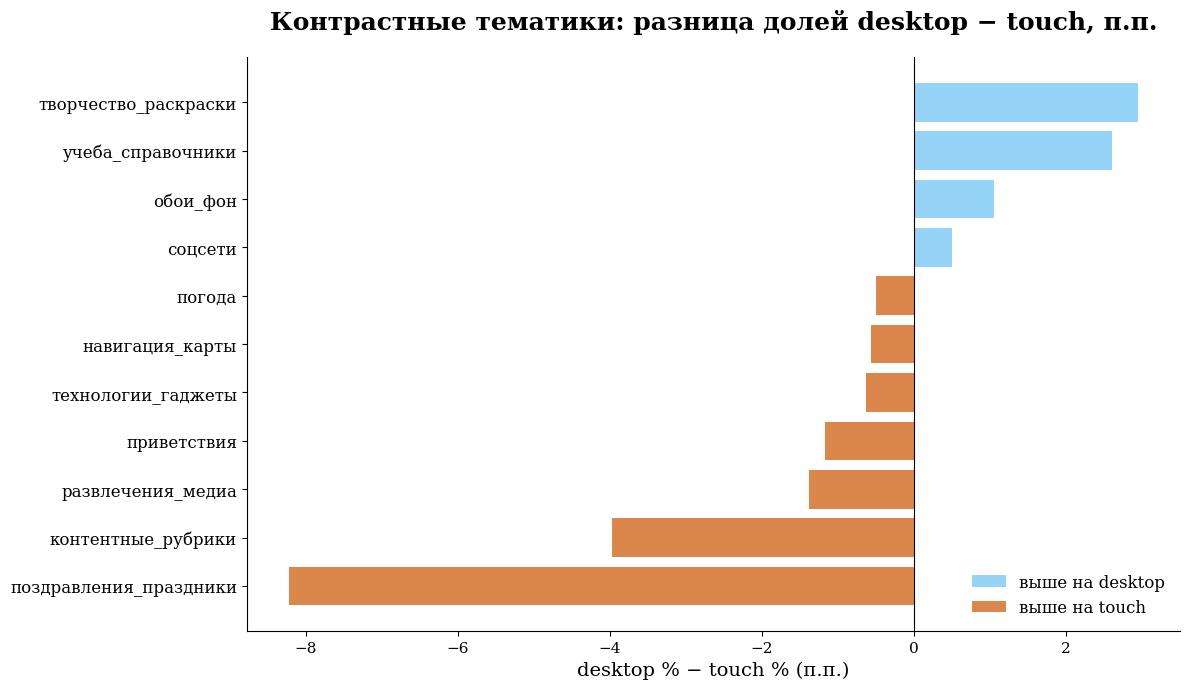

In [16]:
# построим график
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(12, 7))

# синий - выше на desktop, оранжевый - выше на touch
colors = ['#d2691e' if v < 0 else '#7bc8f6' for v in pivot_share['diff']]
ax.barh(pivot_share.index, pivot_share['diff'], color=colors, alpha=0.8)

ax.axvline(0, color='black', linewidth=0.8)  # линия на нуле для ориентира
ax.set_title('Контрастные тематики: разница долей desktop − touch, п.п.', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('desktop % − touch % (п.п.)', fontsize=14)
plt.yticks(fontsize=12)
plt.xticks(fontsize=11)

# легенда собирается вручную, т.к. цвет задан условием (if/else), а не колонкой данных
legend_elements = [
    Patch(facecolor='#7bc8f6', alpha=0.8, label='выше на desktop'),
    Patch(facecolor='#d2691e', alpha=0.8, label='выше на touch'),
]
ax.legend(handles=legend_elements, fontsize=12, loc='lower right', frameon=False)

sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()

**Краткий вывод:**
Категоризация покрыла 27,1% всех запросов (302 082 из 1 114 365) — остальное длинный хвост уникальных и редких формулировок, не поддающийся ручной категоризации без ML.

**Сильнее выражены на touch:**
- поздравления/праздники (touch 10,2% vs desktop 2,0%, разница −8,2 п.п.) — самый заметный разрыв, отражает бытовое использование "здесь и сейчас" (открытки, поздравления)
- "контентные" рубрики — наука, история, мода, спорт и т.п. (−4,0 п.п.) — похоже на тематические разделы новостной/контентной ленты
- развлечения: игры, фильмы, музыка (−1,4 п.п.)
- приветствие "доброе утро" (−1,2 п.п.) — характерно только для мобильного использования

**Сильнее выражены на desktop:**
- творчество/раскраски (+2,9 п.п.) — вероятно, для последующей печати
- учёба/справочники: таблицы, алфавит, карты (+2,6 п.п.)
- обои/фон (+1,1 п.п.) — desktop-специфичное понятие "рабочего стола"

**Общий вывод:** Desktop используется как инструмент для конкретной задачи — найти и, вероятно, сохранить/распечатать справочный или учебный материал. Touch — как канал потребления контента «на ходу»: праздничные открытки, тематические ленты, развлечения, привязанные к бытовым ритуалам дня ("доброе утро", вечерний досуг). Это согласуется и с находками из раздела 4 (desktop активен в дневные "рабочие" часы, touch — утром и вечером) и раздела 3 (топ-10 запросов).

## Резюме по проекту

Цель проекта — проверка гипотезы о том, что интересы пользователей поиска по картинкам на компьютерах и мобильных устройствах заметно различаются. Гипотеза подтвердилась — разница видна сразу в нескольких независимых срезах: в темах запросов, во времени использования и в характере самих запросов.

**Подготовка данных.** Данные охватывают период с 1 по 21 сентября 2021 года (726,1 тыс. запросов с touch, 65,2%, и 388,3 тыс. с desktop, 34,8%). Время переведено из unix-timestamp в московское, т.к. сервис российский — без этого границы дат съезжали бы на 3 часа и выглядели неровно. Также найдены 435 явных дубликатов (0,04% данных): они не распределены случайно, а концентрируются в дни праздников — 1 и 21 сентября (День знаний и Рождество Пресвятой Богородицы). Без user_id нельзя точно определить, технический это повтор или совпадение независимых пользователей, но, учитывая малую долю и правдоподобность естественного совпадения при пиковом спросе, дубликаты оставлены в данных без изменений.

**Находки по пунктам задания.**

Запросы про YouTube — desktop и touch дают почти одинаковые абсолютные числа (806 и 732), но в долях от трафика платформы desktop почти вдвое выше (0,21% против 0,10%). Без нормировки на объём платформы можно было бы сделать неверный вывод о равном интересе к теме на обеих платформах. На деле даже такая узкая и нейтральная тема, как YouTube, подтверждает общий паттерн: на desktop поиск по картинкам используется более целенаправленно, тогда как на touch он размыт среди множества других фоновых запросов.

Топ-10 запросов на платформах не пересекается вообще. На desktop — учебно-справочные темы: таблица Менделеева, алфавит, календарь, карта мира. На touch изначально в топе оказались 4 отдельные формулировки "с днём рождения", искусственно занижающие вес темы; после объединения формулировок тема даёт 55 213 запросов (7,6% трафика touch) против 5 577 на desktop (1,44%) — почти в 5 раз больше в относительном выражении.

Трафик по часам суток показал асимметричный паттерн: touch набирает активность раньше утром (5-9 часов) и снова растёт вечером (20:00-21:00), а desktop держит плато весь рабочий день (11:00-20:00) с пиком около 16:00 — линии пересекаются около 11 утра.

Для контрастных тематик запросы вручную размечены по ключевым словам на основе топ-40 частотных запросов каждой платформы (готовой категоризации в данных нет). Это покрыло 27,1% всех запросов. Самый резкий контраст — тема поздравлений (−8,2 п.п. в пользу touch), за ней контентные рубрики вроде "наука"/"мода"/"спорт" (−4,0 п.п.). В сторону desktop сильнее всего выражены раскраски/творчество (+2,9 п.п.) и учебные справочники (+2,6 п.п.).

**Общий вывод:** desktop и touch — это два разных пользовательских сценария, а не два способа зайти в один и тот же сервис. Desktop используется целенаправленно — найти и, вероятно, сохранить или распечатать конкретный материал для работы/учёбы. Touch — канал фонового потребления контента, встроенный в бытовые ритуалы дня: открытки "здесь и сейчас", утренний и вечерний скролл. Для продукта это означает, что метрики качества поиска и релевантности стоит анализировать раздельно по платформам — усреднённые цифры будут маскировать два противоположных по природе паттерна использования.

# Ссылка на tableau: 
https://public.tableau.com/views/_17838097121720/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link